#  Curso: Introducción a Observabilidad de LLMs

Ya aprendimos a **medir** — offline, contra datasets fijos. Ahora empezamos
con **Observabilidad**, y la pregunta cambia por completo: ya no es *"¿qué tan
bien funciona mi sistema en este conjunto de pruebas?"*, sino *"¿qué está pasando
ahora mismo, con tráfico real, y por qué?"*

Hoy además cruzamos un hito del curso: por primera vez vamos a **ensamblar un sistema completo** — `cloudbox_bot()`. Hasta ahora evaluamos piezas sueltas; desde hoy operamos un sistema.

### Objetivos de esta clase
- ✅ Distinguir evaluación offline de observabilidad en producción
- ✅ Entender los conceptos de **trace**, **span** y **log**, y su relación padre/hijo
- ✅ Saber qué registrar en un span de LLM: prompts, tokens, latencia, costo, metadata
- ✅ Construir un **tracer casero** desde cero (decorador/context manager)
- ✅ Ensamblar y instrumentar `cloudbox_bot()`, el primer sistema completo del curso
- ✅ Simular tráfico real y analizar los traces resultantes (latencia, costo, cuellos de botella)
- ✅ Conocer cómo se ve lo mismo con **LangSmith** (conceptual, sin API key)

### La pregunta central de esta clase

> Tu sistema RAG respondió mal a un usuario a las 3am. No hay excepción, no hay
> stack trace — el código "funcionó". ¿Cómo averiguas qué pasó?


## Instalación de Dependencias

In [ ]:
!pip install transformers torch huggingface_hub pandas matplotlib rank-bm25 -q

## Acceso a Gemma (modelo con licencia)

Si ya ejecutaste `notebook_login()` en una clase anterior de esta sesión de Colab,
puedes saltarte este paso.

1. Entra a **https://huggingface.co/google/gemma-3-1b-it**, inicia sesión y acepta la licencia.
2. Crea un token en **https://huggingface.co/settings/tokens** (alcanza con *Read*).
3. Corre la celda de abajo y pega tu token.

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

## Importaciones y Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import time
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from contextlib import contextmanager
from rank_bm25 import BM25Okapi
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

In [ ]:
print("🔄 Loading LLM...")
model_name = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

🔄 Loading LLM...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [ ]:
llm = pipeline("text-generation", model=model, tokenizer=tokenizer)

In [ ]:
def ask_llm(prompt, max_new_tokens=60, do_sample=False, temperature=0.7):
    messages = [{"role": "user", "content": prompt}]
    kwargs = dict(max_new_tokens=max_new_tokens, do_sample=do_sample,
                  pad_token_id=tokenizer.eos_token_id, return_full_text=False)
    if do_sample:
        kwargs["temperature"] = temperature
    output = llm(messages, **kwargs)
    return output[0]["generated_text"].strip()

print("✅ LLM ready")

✅ LLM ready


---
# PARTE 1: Evaluación offline vs Observabilidad en producción

| | **Evaluación** | **Observabilidad** |
|---|---|---|
| ¿Contra qué mides? | un dataset fijo, curado | tráfico real, que no controlas |
| ¿Cuándo? | antes de desplegar | mientras el sistema corre |
| ¿Qué falla, típicamente? | el sistema da mal una métrica conocida | cosas que *nunca imaginaste probar* |
| ¿Cómo te enteras de un problema? | corriendo el golden set de nuevo | mirando traces, dashboards, alertas |

### El ejemplo de hoy: la comanda de la pizzería

Imagina la cocina de una pizzería. Cada pedido de un cliente pasa por varios pasos:
tomar el pedido, preparar la masa, hornear, entregar. La cocina lleva una **comanda**
por cada pedido — un papelito donde anotan cuándo empezó y terminó cada paso.

Si un cliente se queja de que su pizza tardó 40 minutos, la comanda te dice
**exactamente en qué paso se atascó** — no tienes que adivinar.

Eso es observabilidad. La comanda es, ni más ni menos, lo que en software llamamos
un **trace**.


---
# PARTE 2: Traces, Spans y Logs

## Conceptos fundamentales

- **Trace**: el registro completo de UNA operación de punta a punta (un pedido
  completo, una pregunta de un usuario). Tiene un `trace_id` único.
- **Span**: una unidad de trabajo *dentro* de un trace (un paso: "tomar pedido",
  "hornear"). Tiene su propio `span_id`, un `parent_id` (quién lo contiene), un
  nombre, un inicio, un fin, y **atributos** (metadata libre: temperatura del
  horno, quién cocinó, etc.)
- **Log**: un evento puntual, sin la estructura de árbol de un trace (ej. *"se
  acabó la mozzarella"*). Útil, pero no te dice en qué paso del pedido ocurrió.

### Con la pizzería

Un pedido de Ana es **un trace** (`trace_id = "pedido-042"`). Dentro tiene 4
**spans**: tomar_pedido → preparar_masa → hornear → entregar, cada uno con su
propio inicio y fin. Si alguien grita *"¡se quemó una pizza!"* sin decir de qué
pedido — eso es **un log**, sin conexión al árbol.

### La estructura, formalizada

$$\text{span} = (\underbrace{\texttt{trace\_id}}_{\text{a qué pedido pertenece}},\ \underbrace{\texttt{span\_id}}_{\text{identidad propia}},\ \underbrace{\texttt{parent\_id}}_{\text{quién lo contiene}},\ \texttt{nombre},\ t_{inicio},\ t_{fin},\ \texttt{atributos})$$

$$\text{duración} = t_{fin} - t_{inicio}$$

Todos los spans de un mismo trace comparten `trace_id`. La cadena de `parent_id`
reconstruye el árbol completo — así es como una UI como LangSmith puede dibujar
la vista anidada que seguramente ya viste en algún dashboard.


---
# PARTE 3: Qué registrar en un span de LLM

Además de inicio/fin, un span de un sistema con LLMs típicamente guarda:

| Atributo | Por qué importa |
|---|---|
| **Prompt / completion** | para reproducir y depurar exactamente qué pasó (con cuidado de no loguear PII) |
| **Tokens** (entrada y salida) | insumo directo para costo, y señal de "¿el contexto se está inflando?" |
| **Latencia** | ¿qué paso es el cuello de botella? |
| **Costo** | los LLMs se cobran por token — sin esto, no hay forma de explicar la factura |
| **Modelo y parámetros** | temperature, versión del modelo — para explicar por qué la salida cambió |
| **Metadata de negocio** | ids de documentos recuperados, versión del prompt, id de usuario |

### Costo estimado

$$\text{costo} = \frac{\text{tokens}_{in}}{1000} \cdot \text{precio}_{in} + \frac{\text{tokens}_{out}}{1000} \cdot \text{precio}_{out}$$

Gemma corriendo local no tiene costo por token — pero calculamos esto **como si**
fuera una API de pago (con precios de ejemplo), porque así es como vas a operar
la mayoría de los sistemas reales en el Bloque 3.

### Con la pizzería

La comanda no solo dice "listo" — anota qué ingredientes se usaron (¿prompt?),
cuánta masa se gastó (¿tokens?), cuánto tardó cada paso (¿latencia?), y cuánto
costó esa pizza en insumos (¿costo?). Sin esos detalles, la comanda es casi inútil
para diagnosticar un problema.


---
# PARTE 4: Construyendo un tracer casero

Vamos a construir la pieza central de esta clase: un `start_span()` que cualquier
función puede usar con `with`, y que automáticamente arma el árbol de spans —
sin que tengamos que pasar `trace_id`/`parent_id` a mano en cada llamada.

**El truco**: mantenemos una **pila** (`_span_stack`) con los spans que están
"abiertos" en este momento. Cuando abrimos un span nuevo, su padre es lo que esté
en el tope de la pila; cuando lo cerramos, lo sacamos de la pila y lo archivamos
en `TRACES`. Así el anidamiento del código (`with` dentro de `with`) se traduce
automáticamente en el anidamiento del árbol de spans.

In [ ]:
TRACES = []        # todos los spans YA CERRADOS (archivo plano, como loguearía un sistema real)
_span_stack = []    # spans abiertos AHORA MISMO (la pila que arma el árbol)

@contextmanager
def start_span(name, **attributes):
    span_id = str(uuid.uuid4())[:8]
    parent_id = _span_stack[-1]["span_id"] if _span_stack else None
    trace_id = _span_stack[0]["trace_id"] if _span_stack else str(uuid.uuid4())[:8]

    span = {
        "trace_id": trace_id,
        "span_id": span_id,
        "parent_id": parent_id,
        "name": name,
        "start": time.perf_counter(),
        "attributes": attributes,
    }
    _span_stack.append(span)
    try:
        yield span                      # el código DENTRO del "with" corre aquí
    finally:
        _span_stack.pop()
        span["end"] = time.perf_counter()
        span["duration_ms"] = (span["end"] - span["start"]) * 1000
        TRACES.append(span)

def print_trace_tree(trace_id):
    """Imprime un trace como árbol indentado, igual que lo mostraría LangSmith."""
    spans = [s for s in TRACES if s["trace_id"] == trace_id]
    by_parent = {}
    for s in spans:
        by_parent.setdefault(s["parent_id"], []).append(s)

    def walk(parent_id, depth=0):
        for s in by_parent.get(parent_id, []):
            attrs = ", ".join(f"{k}={v}" for k, v in s["attributes"].items())
            print("  " * depth + f"- {s['name']} ({s['duration_ms']:.1f}ms)" + (f"  [{attrs}]" if attrs else ""))
            walk(s["span_id"], depth + 1)

    walk(None)

print("✅ Tracer listo")

✅ Tracer listo


## Probemos el tracer con la pizzería (antes de meterlo en algo complejo)

In [ ]:
def prepare_pizza_order(cliente):
    with start_span("pedido_completo", cliente=cliente):
        with start_span("tomar_pedido"):
            time.sleep(0.05)
        with start_span("preparar_masa"):
            time.sleep(0.1)
        with start_span("hornear", temperatura="250C"):
            time.sleep(0.15)
        with start_span("entregar"):
            time.sleep(0.02)

prepare_pizza_order("Ana")

print(f"✅ {len(TRACES)} spans registrados\n")
print_trace_tree(TRACES[0]["trace_id"])

✅ 5 spans registrados

- pedido_completo (320.7ms)  [cliente=Ana]
  - tomar_pedido (50.1ms)
  - preparar_masa (100.1ms)
  - hornear (150.1ms)  [temperatura=250C]
  - entregar (20.2ms)


**Verificación rápida** (para confiar en el tracer antes de usarlo en serio):
debería haber exactamente 1 span raíz (sin padre) y 0 spans huérfanos (con un
`parent_id` que no exista).

In [ ]:
root_count = sum(1 for s in TRACES if s["parent_id"] is None)
span_ids = {s["span_id"] for s in TRACES}
orphans = [s for s in TRACES if s["parent_id"] is not None and s["parent_id"] not in span_ids]

print(f"Spans raíz: {root_count} (esperado 1)")
print(f"Spans huérfanos: {len(orphans)} (esperado 0)")
assert root_count == 1 and len(orphans) == 0, "algo está mal en el tracer"
print("✅ Tracer verificado")

Spans raíz: 1 (esperado 1)
Spans huérfanos: 0 (esperado 0)
✅ Tracer verificado


---
# PARTE 5: Ensamblando `cloudbox_bot` — el primer sistema completo del curso

Hasta ahora evaluamos el retriever solo (Clase 2) y la generación sola con contexto
fijo (Clase 3). Hoy los unimos en una función real. Para mantener el foco en
**observabilidad** (no en retrieval), usamos aquí el retriever BM25 puro de la
Clase 2 — instrumentar la versión híbrida completa queda como ejercicio.

In [ ]:
corpus = {
    "plan_01": "CloudBox offers three plans: Free with 5GB of storage, Pro at $9 per month with 500GB, and Team at $15 per user per month with 2TB of shared storage.",
    "plan_02": "Free plan users can upload files up to 2GB each. Pro and Team plan users can upload files up to 100GB each.",
    "plan_03": "If you exceed your storage limit, new uploads are paused, but you can still download and share your existing files.",
    "seg_01": "All files in CloudBox are encrypted with AES-256 at rest and TLS 1.3 in transit. Passwords are never stored in plain text.",
    "seg_02": "Two-factor authentication can be enabled from Settings, Security, using an authenticator app or SMS codes.",
    "seg_03": "If you forget your password, click Forgot password on the login page to receive a reset link by email.",
    "arch_01": "Deleted files stay in the Trash for 30 days before being permanently removed. You can restore them anytime during that window.",
    "arch_02": "CloudBox keeps the last 30 versions of every file for Pro and Team plans, and the last 5 versions for Free plan users.",
    "arch_03": "You can export all your files as a single ZIP archive from Settings, Data Export. Large exports may take a few hours to prepare.",
    "acc_01": "You can share any file or folder by generating a link. Links can be public, restricted to specific email addresses, or protected with a password.",
    "acc_02": "The CloudBox desktop app syncs files automatically in the background. If sync gets stuck, restarting the app or checking your internet connection usually fixes it.",
    "acc_03": "CloudBox has apps for iOS and Android that support offline access to starred files.",
    "colab_01": "Documents can be edited by multiple people at the same time, with changes appearing live for all collaborators.",
    "colab_02": "Team plan folders support granular permissions: viewer, commenter, or editor, assignable per member.",
    "colab_03": "CloudBox integrates with Slack, Google Calendar, and Zapier to automate workflows.",
    "dev_01": "CloudBox offers a REST API for developers to programmatically upload, list, and manage files, rate-limited to 1000 requests per hour.",
    "dev_02": "Free plan users get community forum support. Pro users get email support with a 24-hour response time. Team users get priority live chat support.",
    "dev_03": "You can cancel your Pro or Team subscription anytime from Settings, Billing. You keep access until the end of the current billing period.",
}
doc_ids = list(corpus.keys())
passages = list(corpus.values())

def tokenize(t):
    return t.lower().replace(",", " ").replace(".", " ").split()

bm25 = BM25Okapi([tokenize(p) for p in passages])

print(f"✅ Corpus CloudBox cargado: {len(corpus)} documentos")

✅ Corpus CloudBox cargado: 18 documentos


In [ ]:
# Precios de ejemplo (ficticios) para el cálculo de costo, como si Gemma fuera una API paga
PRICE_PER_1K_INPUT = 0.0001   # USD
PRICE_PER_1K_OUTPUT = 0.0003  # USD

def retrieve(query, k=3):
    with start_span("retrieval", query=query, k=k) as span:
        scores = bm25.get_scores(tokenize(query))
        ranking = np.argsort(scores)[::-1][:k]
        retrieved_ids = [doc_ids[i] for i in ranking]
        retrieved_docs = [corpus[d] for d in retrieved_ids]
        span["attributes"]["retrieved_ids"] = retrieved_ids   # se puede enriquecer el span DESPUÉS de abrirlo
        span["attributes"]["top_score"] = float(scores[ranking[0]]) if len(ranking) else 0.0
    return retrieved_docs, retrieved_ids

def generate(query, context_docs):
    context = " ".join(context_docs)
    prompt = f"Answer based on the context, in one short sentence.\n\nContext: {context}\n\nQuestion: {query}\n\nAnswer:"

    with start_span("generation", model=model_name) as span:
        input_tokens = len(tokenizer(prompt)["input_ids"])
        answer = ask_llm(prompt, max_new_tokens=60)
        output_tokens = len(tokenizer(answer)["input_ids"])
        cost = (input_tokens / 1000) * PRICE_PER_1K_INPUT + (output_tokens / 1000) * PRICE_PER_1K_OUTPUT

        span["attributes"]["input_tokens"] = input_tokens
        span["attributes"]["output_tokens"] = output_tokens
        span["attributes"]["cost_usd"] = round(cost, 6)
    return answer

def cloudbox_bot(query):
    with start_span("cloudbox_request", query=query):
        docs, ids = retrieve(query)
        answer = generate(query, docs)
    return answer

print("✅ cloudbox_bot ensamblado")

✅ cloudbox_bot ensamblado


## Probemos con una sola pregunta, y miremos su trace

In [ ]:
TRACES.clear()  # arrancamos limpio para este experimento

respuesta = cloudbox_bot("How long do deleted files stay in the Trash?")
print(f"🤖 Respuesta: {respuesta}\n")

print("🌳 Trace completo:\n")
print_trace_tree(TRACES[0]["trace_id"])

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


🤖 Respuesta: Deleted files stay in the Trash for 30 days before being permanently removed.

🌳 Trace completo:

- cloudbox_request (2714.2ms)  [query=How long do deleted files stay in the Trash?]
  - retrieval (6.0ms)  [query=How long do deleted files stay in the Trash?, k=3, retrieved_ids=['arch_01', 'seg_01', 'acc_02'], top_score=7.187892657370297]
  - generation (2708.1ms)  [model=google/gemma-3-1b-it, input_tokens=119, output_tokens=17, cost_usd=1.7e-05]


---
# PARTE 6: Simulando tráfico real

Un solo trace no enseña mucho sobre patrones. Simulamos un lote de preguntas de
usuarios — algunas típicas, una de jerga técnica, una fuera de dominio (donde el
retriever no va a encontrar nada bueno) — como llegarían en un rato de uso real.

In [ ]:
simulated_traffic = [
    "How much storage does the Pro plan include?",
    "What encryption does CloudBox use?",
    "How long do deleted files stay in the Trash?",
    "AES-256 TLS 1.3",
    "Can I share a file with a password?",
    "What is CloudBox's refund policy?",          # fuera de dominio, a propósito
    "How do I enable two-factor authentication?",
    "What happens if I exceed my storage limit?",
]

TRACES.clear()

print(f"🔄 Procesando {len(simulated_traffic)} queries simuladas...\n")
for q in simulated_traffic:
    respuesta = cloudbox_bot(q)
    print(f"❓ {q}\n🤖 {respuesta}\n")

print(f"✅ {len(TRACES)} spans registrados en total")

[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔄 Procesando 8 queries simuladas...



[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❓ How much storage does the Pro plan include?
🤖 The Pro plan includes 500GB of storage.



[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

❓ Can I share a file with a password?
🤖 Yes, you can share files with a password through the Settings, Data Export feature.



[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❓ What is CloudBox's refund policy?
🤖 CloudBox offers a REST API with rate limits, allowing developers to programmatically upload, list, and manage files.



[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❓ How do I enable two-factor authentication?
🤖 You can enable two-factor authentication through Settings, Security, using an authenticator app or SMS codes.

❓ What happens if I exceed my storage limit?
🤖 New uploads are paused when you exceed your storage limit.

✅ 24 spans registrados en total


---
# PARTE 7: Analizando los traces (un mini-dashboard)

Convertimos `TRACES` a un DataFrame — así es, literalmente, como se ve el storage
detrás de un dashboard de observabilidad real.

## Percentiles de latencia

El promedio esconde outliers. Por eso la industria reporta **percentiles**:

$$p_{95} = \text{el valor por debajo del cual cae el 95\% de las observaciones}$$

Si $p_{50}$ (la mediana) es 200ms pero $p_{95}$ es 3000ms, significa que el 95% de
tus usuarios tiene una buena experiencia... pero 1 de cada 20 espera 15 veces más.
Ese 5% son casos reales que un promedio disimula por completo.

In [ ]:
df = pd.DataFrame(TRACES)

print("Vista general de los spans:\n")
print(df[["trace_id", "name", "duration_ms"]].to_string(index=False))

Vista general de los spans:

trace_id             name  duration_ms
2475548a        retrieval     0.333608
2475548a       generation  2145.788060
2475548a cloudbox_request  2146.186229
ece340f0        retrieval     0.243347
ece340f0       generation  2910.840069
ece340f0 cloudbox_request  2911.143476
512269ab        retrieval     0.356949
512269ab       generation  1937.108248
512269ab cloudbox_request  1937.546478
4ca61863        retrieval     0.232262
4ca61863       generation  1926.252559
4ca61863 cloudbox_request  1926.550113
8145e3c5        retrieval     0.309675
8145e3c5       generation  1701.653111
8145e3c5 cloudbox_request  1702.024306
21ddf8cb        retrieval     0.246393
21ddf8cb       generation  3026.776806
21ddf8cb cloudbox_request  3027.079328
0a252efb        retrieval     0.275942
0a252efb       generation  3132.722943
0a252efb cloudbox_request  3133.060726
ae807000        retrieval     0.323359
ae807000       generation  1635.900952
ae807000 cloudbox_request  1636.287

In [ ]:
# Latencia por TIPO de span (para encontrar el cuello de botella)
latency_by_span = df.groupby("name")["duration_ms"].agg(["mean", "count"])
print("⏱️  Latencia promedio por tipo de span:\n")
print(latency_by_span)

# Percentiles sobre la latencia TOTAL de cada request (el span raíz)
root_durations = df[df["name"] == "cloudbox_request"]["duration_ms"].sort_values().values
p50 = np.percentile(root_durations, 50)
p95 = np.percentile(root_durations, 95)

print(f"\n📊 Latencia total por request:")
print(f"   p50 = {p50:.0f}ms")
print(f"   p95 = {p95:.0f}ms")

# Costo total del lote
total_cost = df[df["name"] == "generation"]["attributes"].apply(lambda a: a.get("cost_usd", 0)).sum()
print(f"\n💰 Costo total del lote: ${total_cost:.6f}")
print(f"💰 Costo promedio por request: ${total_cost/len(simulated_traffic):.6f}")

⏱️  Latencia promedio por tipo de span:

                         mean  count
name                                
cloudbox_request  2302.484781      8
generation        2302.130344      8
retrieval            0.290192      8

📊 Latencia total por request:
   p50 = 2042ms
   p95 = 3096ms

💰 Costo total del lote: $0.000133
💰 Costo promedio por request: $0.000017


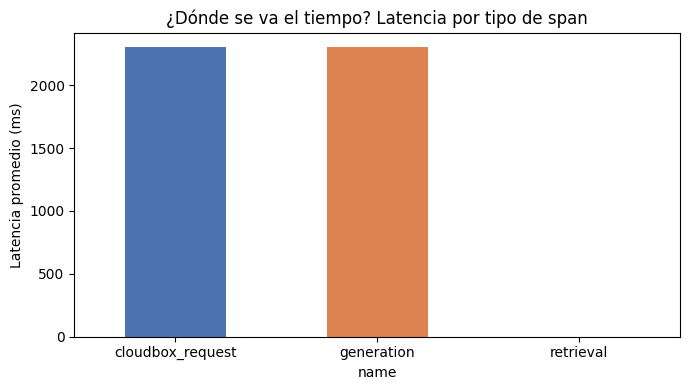


❓ Discusión: ¿retrieval o generation es el cuello de botella? ¿Tiene sentido con
   lo que sabes de cada uno (BM25 es casi instantáneo; un LLM genera token a
   token)? En un sistema real, esto te dice DÓNDE vale la pena optimizar.



In [ ]:
# Visualización: latencia promedio por tipo de span
plt.figure(figsize=(7, 4))
latency_by_span["mean"].plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Latencia promedio (ms)")
plt.title("¿Dónde se va el tiempo? Latencia por tipo de span")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
❓ Discusión: ¿retrieval o generation es el cuello de botella? ¿Tiene sentido con
   lo que sabes de cada uno (BM25 es casi instantáneo; un LLM genera token a
   token)? En un sistema real, esto te dice DÓNDE vale la pena optimizar.
""")

## Buscando la aguja en el pajar: la query fuera de dominio

Recuerda que incluimos a propósito *"What is CloudBox's refund policy?"* — una
pregunta que el corpus no puede responder bien. Busquémosla en los traces.

In [ ]:
ood_trace = df[(df["name"] == "retrieval") &
               (df["attributes"].apply(lambda a: "refund" in a.get("query", "").lower()))]

if not ood_trace.empty:
    row = ood_trace.iloc[0]
    print(f"🔍 Query fuera de dominio encontrada:")
    print(f"   query: {row['attributes']['query']}")
    print(f"   documentos recuperados: {row['attributes']['retrieved_ids']}")
    print(f"   top_score: {row['attributes']['top_score']:.2f}")
    print("""
💡 En producción, un top_score de retrieval anormalmente bajo (comparado con el
   resto del tráfico) es justo el tipo de señal que un sistema de ALERTAS
   (Clase 7) usaría para avisarte: "esta respuesta probablemente sea mala,
   revísala" — sin que ningún usuario tenga que quejarse primero.
""")

🔍 Query fuera de dominio encontrada:
   query: What is CloudBox's refund policy?
   documentos recuperados: ['dev_03', 'dev_02', 'dev_01']
   top_score: 0.00

💡 En producción, un top_score de retrieval anormalmente bajo (comparado con el
   resto del tráfico) es justo el tipo de señal que un sistema de ALERTAS
   (Clase 7) usaría para avisarte: "esta respuesta probablemente sea mala,
   revísala" — sin que ningún usuario tenga que quejarse primero.



---
# PARTE 8: Cómo se vería con LangSmith

No vamos a ejecutar esto (requiere una cuenta y una API key), pero vale la pena
ver la traducción directa: **todo lo que construimos a mano hoy, LangSmith te lo
da envolviendo tus funciones con un decorador.**

```python
# pip install langsmith
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "tu-api-key"

from langsmith import traceable

@traceable(name="retrieval")
def retrieve(query, k=3):
    ...   # exactamente el mismo código, sin nuestro start_span() manual

@traceable(name="generation")
def generate(query, context_docs):
    ...

@traceable(name="cloudbox_request")
def cloudbox_bot(query):
    docs, ids = retrieve(query)
    return generate(query, docs)
```

Con eso, cada llamada a `cloudbox_bot()` aparece automáticamente en el dashboard
de LangSmith — el mismo árbol que `print_trace_tree()` te mostró en la Parte 5,
pero con una UI, historial persistente, filtros, y (en la Clase 6) evaluadores
integrados. **La mecánica de fondo es exactamente la que programaste hoy** —
`trace_id`, `span_id`, `parent_id`, atributos — solo que ya no la mantienes tú.

Alternativas open-source con la misma idea: **Langfuse**, **Phoenix (Arize)**, y
el estándar **OpenTelemetry**, que veremos en la Clase 6.


---
# Ejercicios Propuestos

1. **Retriever híbrido instrumentado**: reemplaza `retrieve()` para que use el
   retriever híbrido (BM25 + embeddings + RRF) de la Clase 2 en vez de solo BM25.
   Agrega un span propio para cada componente (`semantic_search`, `bm25_search`,
   `rrf_fusion`) anidado dentro de `retrieval`. ¿Cómo cambia el árbol del trace?

2. **Alertas simples**: escribe una función que recorra `TRACES` y marque como
   "sospechoso" cualquier request donde `retrieval.top_score` esté por debajo de
   un umbral, o donde `generation.duration_ms` supere el p95 del lote. Esto es,
   literalmente, el prototipo de un sistema de alertas (Clase 7).

3. **Logs vs Spans**: agrega una función `log_event(message, **kwargs)` que
   registre eventos SIN estructura de árbol (a diferencia de un span) — por
   ejemplo, para loguear cuando `retrieve()` no encuentra ningún documento con
   score razonable. ¿Cuándo usarías un log en vez de un span?

4. **Judge instrumentado**: agrega un tercer span `judge` dentro de
   `cloudbox_request`, que llame a `judge_pointwise` de la Clase 4 sobre cada
   respuesta generada, y guarda el score como atributo. Ahora tu trace también
   registra CALIDAD, no solo latencia y costo.

5. **Percentiles con más tráfico**: genera 30 queries simuladas (puedes mezclar
   variaciones de las 8 originales) y recalcula p50/p95/p99. ¿Cambia mucho la
   forma de la distribución con más datos?

6. **Comparar dos versiones del prompt**: cambia el prompt de `generate()` y
   corre el mismo lote de tráfico. Compara latencia, tokens y costo entre
   ambas versiones — el inicio de lo que en la Clase 9 vas a formalizar como
   A/B testing de prompts.


---
# Conclusión

### Ideas clave
1. **Evaluación mide contra un dataset fijo; observabilidad vigila un sistema vivo**
   — son complementarias, no sustitutas
2. Un **trace** es una request completa; un **span** es un paso dentro de ella;
   un **log** es un evento suelto sin estructura de árbol
3. Lo mínimo que vale la pena registrar en un span de LLM: prompt/completion,
   tokens, latencia, costo, y metadata de negocio (ids recuperados, versión de prompt)
4. Los **percentiles** (p95, p99) revelan problemas que el promedio esconde
5. Hoy ensamblaste tu **primer sistema completo** (`cloudbox_bot`) — a partir de
   ahora, todo el curso trabaja sobre sistemas, no solo componentes sueltos
6. Herramientas como LangSmith automatizan exactamente la mecánica que programaste
   hoy a mano — entenderla te permite depurarlas cuando algo no cuadra

### Próxima clase

**Plataformas de observabilidad**: LangSmith en profundidad, alternativas
open-source (Langfuse, Phoenix/Arize, OpenTelemetry), y cómo tracear agentes
multi-paso — como el retry loop con ciclos del notebook 12, donde un trace plano
ya no alcanza y necesitamos representar el grafo completo de ejecución.
